In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from DataLoader import Dataloader
from Engine import Engine
import Information as info
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

c:\Python Interpreters\in_Machine_Learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
data_path = Path(r"D:\All Python\Kaggle\data\house_prices\train.csv")
dataloader = Dataloader(data_path=data_path, seed=42)
dataloader.data

d:\All Python\Kaggle\Project 2 - House Pricing\Decision_Tree\DataLoader.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.data["Alley"].fillna(0, inplace=True)
d:\All Python\Kaggle\Project 2 - House Pricing\Decision_Tree\DataLoader.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

,SalePrice,LotArea,Street,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,208500,8450,1,7,5,2003,2003,196.0,4,3,...,0,0,0,1,0,0,0,0,1,0
2,181500,9600,1,6,8,1976,1976,0.0,3,3,...,0,0,0,1,0,0,0,0,1,0
3,223500,11250,1,7,5,2001,2002,162.0,4,3,...,0,0,0,1,0,0,0,0,1,0
4,140000,9550,1,7,5,1915,1970,0.0,3,3,...,0,0,0,1,1,0,0,0,0,0
5,250000,14260,1,8,5,2000,2000,350.0,4,3,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,175000,7917,1,6,5,1999,2000,0.0,3,3,...,0,0,0,1,0,0,0,0,1,0
1457,210000,13175,1,6,6,1978,1988,119.0,3,3,...,0,0,0,1,0,0,0,0,1,0
1458,266500,9042,1,7,9,1941,2006,0.0,5,4,...,0,0,0,1,0,0,0,0,1,0


[INFO] Data splitted to X and Y.
Accuracy for Train is 0.8156898812538389
Accuracy for Test is 0.740669426246612


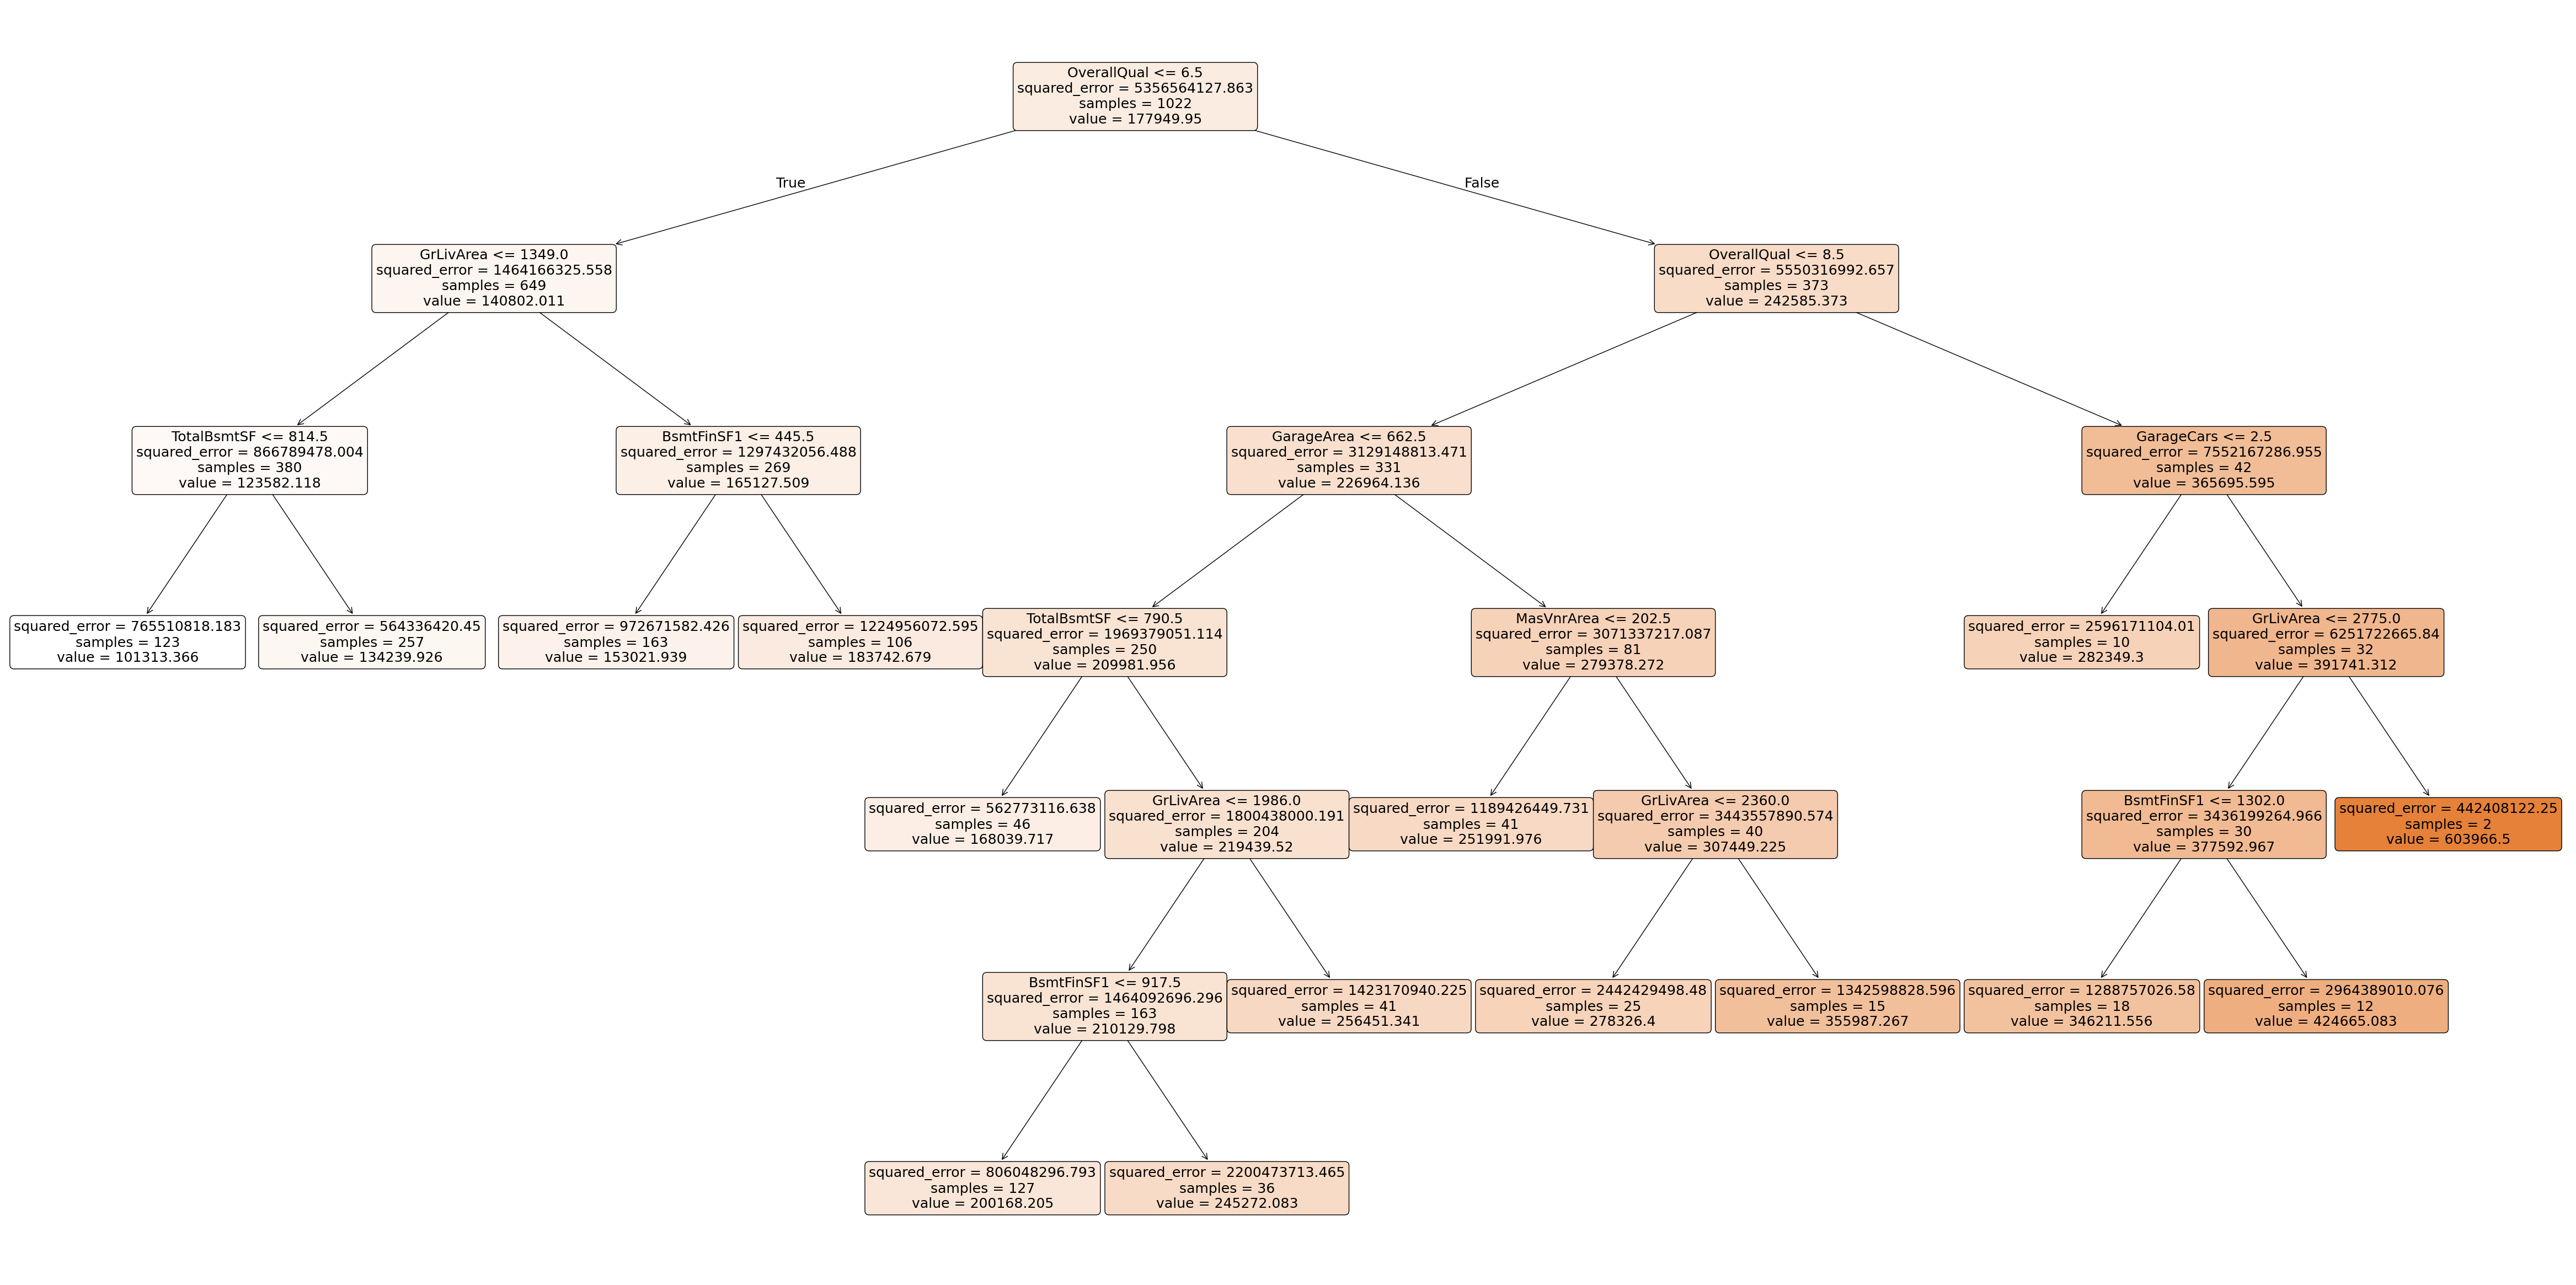

In [6]:
model = Engine(data=dataloader.data, seed=542)
model.fit(alpha=42851072.73274174, if_plot_tree=True)


100%|██████████| 961/961 [00:39<00:00, 24.14it/s]


best alpha for test is:4313052.026205834


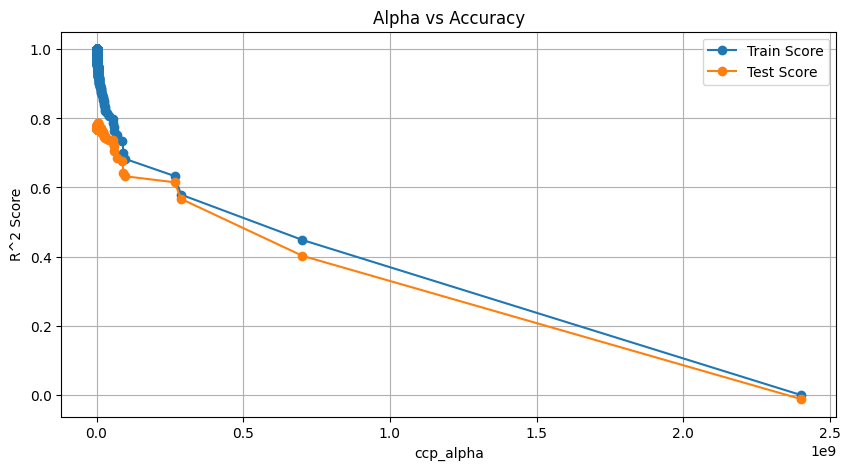

In [5]:
model.find_best_alpha()

100%|██████████| 960/960 [03:06<00:00,  5.14it/s]


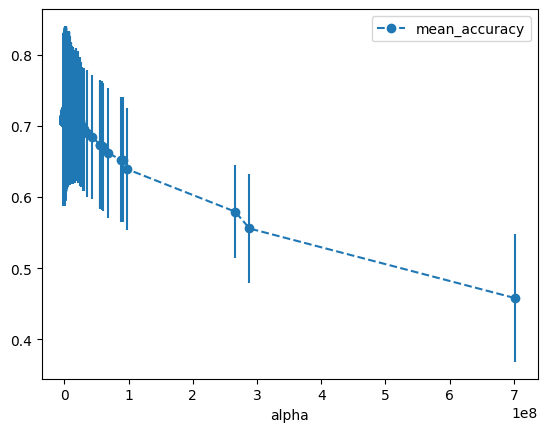

In [6]:
model.cross_validation_to_find_best_alpha()

In [7]:
model.alpha_result
# 42851072.73274174

,alpha,mean_accuracy,std
0,0.000000e+00,0.705981,0.119073
1,1.223092e+00,0.705982,0.119073
2,4.892368e+00,0.705981,0.119073
3,4.892368e+00,0.705981,0.119073
4,4.892368e+00,0.705981,0.119073
...,...,...,...
955,9.161376e+07,0.652161,0.087797
956,9.703312e+07,0.639444,0.085450
957,2.660027e+08,0.579470,0.065414
958,2.882830e+08,0.555880,0.076041


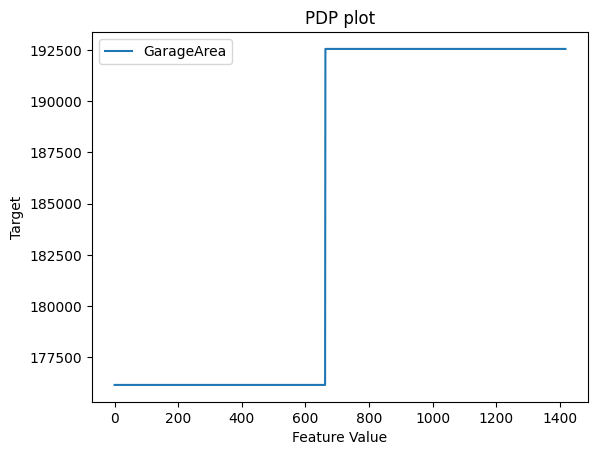

In [ ]:
features1 = {"OverallQual":[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}
features2 = {"YearRemodAdd": list(range(1950, 2011))}
features3 = {"GarageArea": sorted(list(model.data["GarageArea"].unique()))}
features4 = {"OverallQual":[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
             "GarageArea": sorted(list(model.data["GarageArea"].unique()))}
model.partial_dependence_plot(features=features3)

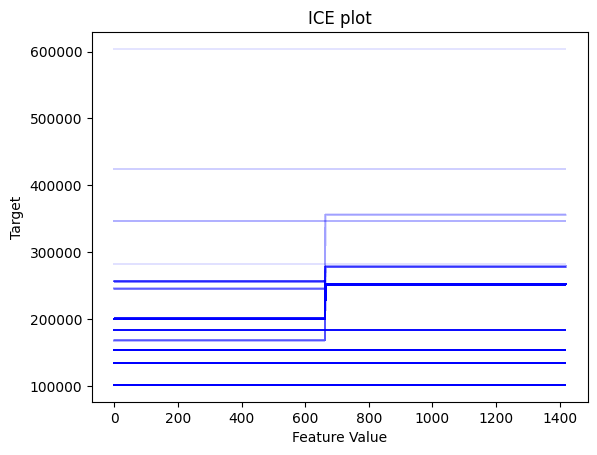

In [18]:
model.individual_conditional_expectation(features=features3)

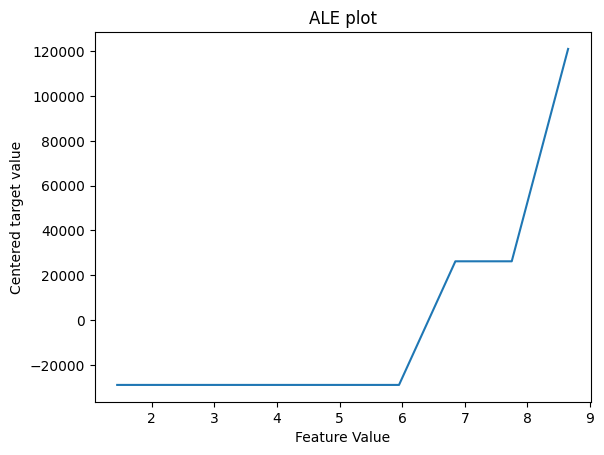

In [114]:
features = ["OverallQual", "YearRemodAdd", "GarageArea", "OverallQual"]
model.accumulated_local_effects_plot(features=[features[3]], n=10)